<a href="https://colab.research.google.com/github/amelsbita/Segmentation_meniscus/blob/main/Unet_Resnet_Backbone_Meniscal_Lesion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Meniscal Segmentation (for Cropped_Images)**

In [ ]:
# Pour accéder au Gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/All_Data_march_2023/cropped_images
!ls

[Errno 2] No such file or directory: '/content/drive/MyDrive/All_Data_march_2023/cropped_images'
/content
drive  sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install segmentation_models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.3 MB/s eta 0:00:00


[Segmentation Models](https://github.com/qubvel/segmentation_models)   (Link)

In [ ]:
import tensorflow as tf
# sm.set_framework('tf.keras')
# sm.framework()
SM_FRAMEWORK=tf.keras
%env SM_FRAMEWORK=tf.keras

env: SM_FRAMEWORK=tf.keras


In [ ]:
import segmentation_models as sm
import glob
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
# import keras
from tensorflow import keras

# from keras.utils.np_utils import normalize
from keras.metrics import MeanIoU

Segmentation Models: using `tf.keras` framework.


In [ ]:
sm.set_framework('tf.keras')
keras.backend.set_image_data_format('channels_last')

In [ ]:
#Resizing images, if needed
SIZE_X = 256
SIZE_Y = 256
n_classes=2 #Number of classes for segmentation

In [ ]:
Pr_Path= '/content/drive/MyDrive/Matsère_recherche_Amel_SBITA_2022/Data/All_Data_march_2023'
print(os.listdir(Pr_Path))

['images', 'Seg_Crop', 'Seg_Results', 'cropped_images']


In [ ]:
train_images = []
Im_Path =glob.glob(Pr_Path + "/cropped_images/*.png")
Im_Path.sort()
Num_Image = len(Im_Path)
#Capture training image info as a list
for Image_Id in Im_Path[0:Num_Image ]:
  # print(directory_path)
  # for img_path in glob.glob(os.path.join(directory_path, "*.png")):
  # print(Image_Id)
  img = cv2.imread(Image_Id, 1)
  img = cv2.resize(img, (SIZE_Y, SIZE_X))
  train_images.append(img)

In [ ]:
#Convert list to array for machine learning processing
train_images = np.array(train_images)

In [ ]:
np.unique(img)

array([  9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,
        22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,
        35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,
        48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,
        61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,
        74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,
        87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99,
       100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151],
      dtype=uint8)

In [ ]:
print(train_images.shape)

(1130, 256, 256, 3)


In [ ]:
# print(train_images.shape)
# keras.__version__

In [ ]:
#Capture mask/label info as a list
train_masks = []
Im_Path =glob.glob(Pr_Path + "/Seg_Crop/*.png")
Im_Path.sort()
Num_Image = len(Im_Path)
for Image_Id in Im_Path[0:Num_Image]:
  # for mask_path in glob.glob(os.path.join(directory_path, "*.tiff")):
  mask = cv2.imread(Image_Id, 0)
  # print(Image_Id)
  U=np.unique(mask)
  # if len(U)
  # print(U)
  # print(mask_path)
  mask = cv2.resize(mask, (SIZE_Y, SIZE_X), interpolation = cv2.INTER_NEAREST)  #Otherwise ground truth changes due to interpolation
  train_masks.append(mask)
#Convert list to array for machine learning processing
train_masks = np.array(train_masks)

In [ ]:
np.unique(mask)

array([0, 1], dtype=uint8)

In [ ]:
print(train_masks.shape)

(1130, 256, 256)


In [ ]:
# This cell is coded with another access method to images

# #Capture mask/label info as a list
# train_masks = []
# for directory_path in glob.glob("/content/drive/MyDrive/CMUCU_PROJECT/Fire_Smoke_Segmentation/Full_dataset_448/Masks_full_256"):
#     for mask_path in glob.glob(os.path.join(directory_path, "*.tiff")):
#         mask = cv2.imread(mask_path, 0)
#         print(mask_path)
#         U=np.unique(mask)
#         # if len(U)
#         print(U)
#         # print(mask_path)
#         #mask = cv2.resize(mask, (SIZE_Y, SIZE_X), interpolation = cv2.INTER_NEAREST)  #Otherwise ground truth changes due to interpolation
#         train_masks.append(mask)
# #Convert list to array for machine learning processing
# train_masks = np.array(train_masks)

In [ ]:
print(train_masks.shape)
# L=int(len(train_masks))
# R=[]
# j=0
# for i in range(L):
#   U=np.unique(train_masks[i])
#   print(i)
#   print(U)

In [ ]:
###############################################
#Encode labels... but multi dim array so need to flatten, encode and reshape
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
n, h, w = train_masks.shape
train_masks_reshaped = train_masks.reshape(-1,1)
train_masks_reshaped_encoded = labelencoder.fit_transform(train_masks_reshaped)
train_masks_encoded_original_shape = train_masks_reshaped_encoded.reshape(n, h, w)
np.unique(train_masks_encoded_original_shape)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 1])

In [ ]:
#################################################
#train_images = np.expand_dims(train_images, axis=3)
#train_images = normalize(train_images, axis=1)
train_masks_input = np.expand_dims(train_masks_encoded_original_shape, axis=3)

In [ ]:
print(train_masks_encoded_original_shape.shape)
print(train_masks_input.shape)

(1130, 256, 256)
(1130, 256, 256, 1)


In [ ]:
#Create a subset of data for quick testing
#Picking 10% for testing and remaining for training
from sklearn.model_selection import train_test_split
X1, X_test, y1, y_test = train_test_split(train_images, train_masks_input, test_size = 0.2, random_state = 0)
#Further split training data t a smaller subset for quick testing of models
X_train, X_do_not_use, y_train, y_do_not_use = train_test_split(X1, y1, test_size = 1, random_state = 0)
print("Class values in the dataset are ... ", np.unique(y_train))  # 0 is the background/few unlabeled
from tensorflow.keras.utils import to_categorical
train_masks_cat = to_categorical(y_train, num_classes=n_classes)
y_train_cat = train_masks_cat.reshape((y_train.shape[0], y_train.shape[1], y_train.shape[2], n_classes))
test_masks_cat = to_categorical(y_test, num_classes=n_classes)
y_test_cat = test_masks_cat.reshape((y_test.shape[0], y_test.shape[1], y_test.shape[2], n_classes))

Class values in the dataset are ...  [0 1]


In [ ]:
# print(X_test)

In [ ]:
# print(y_test_cat.shape)

In [ ]:
######################################################
#Reused parameters in all models
n_classes=2
activation='softmax'

LR = 0.0001
optim = keras.optimizers.Adam(LR)

# Segmentation models losses can be combined together by '+' and scaled by integer or float factor
# set class weights for dice_loss (Meniscal: 0.5, Others: 0.5)
dice_loss = sm.losses.DiceLoss(class_weights=np.array([0.5,0.5]))
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

# actulally total_loss can be imported directly from library, above example just show you how to manipulate with losses
# total_loss = sm.losses.binary_focal_dice_loss # or sm.losses.categorical_focal_dice_loss

metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]


In [ ]:
# print(np.shape(X_test1))

In [ ]:
########################################################################
###Model 1
BACKBONE1 = 'resnet101'
preprocess_input1 = sm.get_preprocessing(BACKBONE1)
# preprocess input
X_train1 = preprocess_input1(X_train)
X_test1 = preprocess_input1(X_test)

# define model
model1 = sm.Unet(BACKBONE1, encoder_weights='imagenet', classes=n_classes, activation=activation)

# compile keras model with defined optimozer, loss and metrics
model1.compile(optim, total_loss, metrics=metrics)

#model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=metrics)

print(model1.summary())

171164896/171164896 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)         │ (None, None, None, 3)  │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_data                   │ (None, None, None, 3)  │              9 │ data[0][0]             │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, None, None, 3)  │              0 │ bn_data[0][0]          │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv0 (Conv2D)            │ (None, None, None, 64) │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn0 (BatchNormalization)  │ (None, None, None, 64) │            256 │ conv0[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ relu0 (Activation)        │ (None, None, None, 64) │              0 │ bn0[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, None, None, 64) │              0 │ relu0[0][0]            │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pooling0 (MaxPooling2D)   │ (None, None, None, 64) │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_unit1_bn1          │ (None, None, None, 64) │            256 │ pooling0[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_unit1_relu1        │ (None, None, None, 64) │              0 │ stage1_unit1_bn1[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_unit1_conv1        │ (None, None, None, 64) │          4,096 │ stage1_unit1_relu1[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_unit1_bn2          │ (None, None, None, 64) │            256 │ stage1_unit1_conv1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_unit1_relu2        │ (None, None, None, 64) │              0 │ stage1_unit1_bn2[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_2          │ (None, None, None, 64) │              0 │ stage1_unit1_relu2[0]… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_unit1_conv2        │ (None, None, None, 64) │         36,864 │ zero_padding2d_2[0][0] │
│ (Conv2D)             

 Total params: 51,605,611 (196.86 MB)

 Trainable params: 51,505,829 (196.48 MB)

 Non-trainable params: 99,782 (389.77 KB)

None


In [ ]:
print(np.shape(X_train1))
print(np.shape(y_train_cat))

(903, 256, 256, 3)
(903, 256, 256, 2)


In [ ]:
y_train_cat.dtype

dtype('float64')

In [ ]:
# Fitting
history1=model1.fit(X_train1,
          y_train_cat,
          batch_size=32,
          epochs=10,
          verbose=1,
          validation_data=(X_test1, y_test_cat))

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 977ms/step - f1-score: 0.9843 - iou_score: 0.9694 - loss: 0.5110 - val_f1-score: 0.9135 - val_iou_score: 0.8496 - val_loss: 0.5593
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 906ms/step - f1-score: 0.9838 - iou_score: 0.9685 - loss: 0.5112 - val_f1-score: 0.9141 - val_iou_score: 0.8504 - val_loss: 0.5592
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 902ms/step - f1-score: 0.9841 - iou_score: 0.9691 - loss: 0.5110 - val_f1-score: 0.9098 - val_iou_score: 0.8441 - val_loss: 0.5622
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 938ms/step - f1-score: 0.9838 - iou_score: 0.9686 - loss: 0.5112 - val_f1-score: 0.9134 - val_iou_score: 0.8495 - val_loss: 0.5598
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 905ms/step - f1-score: 0.9855 - iou_score: 0.9718 - loss: 0.5101 - val_f1-score: 0.9146 - val_iou_score: 0.8512 - val_loss: 0.5595
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 922ms/step - f1-score: 0.9856 - iou_score: 0.9718 - loss: 0.5101 - val_f1-score: 0.9139 - val

In [ ]:
# print(X_train1.shape)

In [ ]:
%cd /content/drive/MyDrive/Students_Lab/Mensical_Lesion/Saved_Models/
!ls

[Errno 2] No such file or directory: '/content/drive/MyDrive/Students_Lab/Mensical_Lesion/Saved_Models/'
/content
drive  sample_data


In [ ]:
# Save Model
model1.save('resnet101_backbone_cropped_BIS_10_epochs.keras')

In [ ]:
print(y_test_cat.shape )
print(np.shape(X_test1))
print(np.shape(y_test_cat))

(226, 256, 256, 2)
(226, 256, 256, 3)
(226, 256, 256, 2)


[Errno 2] No such file or directory: '/content/drive/MyDrive/Students_Lab/Mensical_Lesion/Saved_Graphs'
/content


<ipython-input-37-d47cd81c2d0c>:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "y" (-> color=(0.75, 0.75, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'y', label='Training loss', color='k')
<ipython-input-37-d47cd81c2d0c>:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'r', label='Validation loss', color='b')


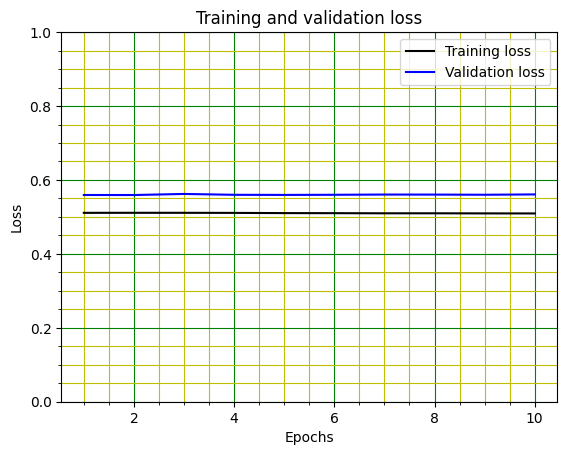

<ipython-input-37-d47cd81c2d0c>:38: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "y" (-> color=(0.75, 0.75, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, acc, 'y', label='Training IOU', color='r')
<ipython-input-37-d47cd81c2d0c>:39: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_acc, 'r', label='Validation IOU', color='b')


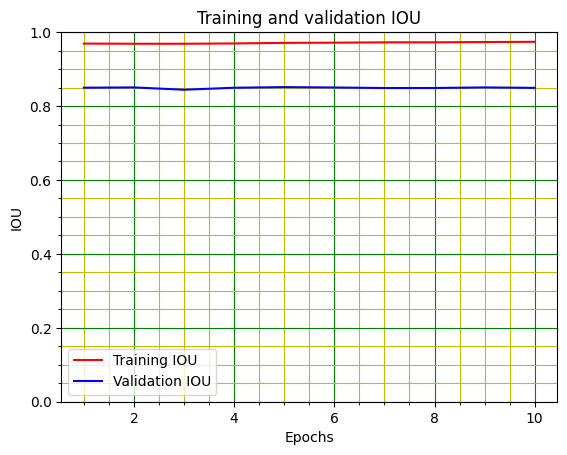

In [ ]:
# Show and Save figures
%cd /content/drive/MyDrive/Students_Lab/Mensical_Lesion/Saved_Graphs
##########################################################
#plot the training and validation accuracy and loss at each epoch
# ---------------------------------------------------------------
#                                  LOSS
# ---------------------------------------------------------------
loss = history1.history['loss']
val_loss = history1.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss', color='k')
plt.plot(epochs, val_loss, 'r', label='Validation loss', color='b')
plt.grid(True, 'major', color='g')
plt.grid(True, 'minor', color='y')
plt.minorticks_on()

plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.ylim([0, 1])
plt.savefig("Train_Val_LOSS.pdf", dpi=150)
plt.savefig("Train_Val_LOSS.eps", dpi=150)

if not plt.rcParams["text.usetex"]:
    plt.savefig("Train_Val_LOSS.svg", dpi=150)




plt.show()
# ---------------------------------------------------------------
#                                  ACCURACY
# ---------------------------------------------------------------
acc = history1.history['iou_score']
val_acc = history1.history['val_iou_score']

plt.plot(epochs, acc, 'y', label='Training IOU', color='r')
plt.plot(epochs, val_acc, 'r', label='Validation IOU', color='b')
plt.title('Training and validation IOU')
plt.xlabel('Epochs')
plt.ylabel('IOU')
plt.legend()
plt.grid(True, 'major', color='g')
plt.grid(True, 'minor', color='y')
plt.minorticks_on()
plt.ylim([0, 1])
# Save figure
# Save files in pdf and eps format
plt.savefig("Train_Val_IOU.pdf", dpi=150)
plt.savefig("Train_Val_IOU.eps", dpi=150)

if not plt.rcParams["text.usetex"]:
    plt.savefig("Train_Val_IOU.svg", dpi=150)

plt.show()


In [ ]:
%cd /content/drive/MyDrive/Students_Lab/Mensical_Lesion/Saved_Models/
!ls

In [ ]:
#####################################################
from keras.models import load_model
#Set compile=False as we are not loading it for training, only for prediction.
model1 = load_model('resnet101_backbone_cropped_BIS_10_epochs.keras', compile=False)
pred1 = model1.predict(X_test1)
y_pred1_argmax=np.argmax(pred1, axis=3)

#Using built in keras function
n_classes = 2
IOU1 = MeanIoU(num_classes=n_classes)
IOU1.update_state(y_test[:,:,:,0], y_pred1_argmax)
print('IOU Score for model1 = ', IOU1.result().numpy())

8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
IOU Score for model1 =  0.850065


In [ ]:
# print(Y_test.shape)

154
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


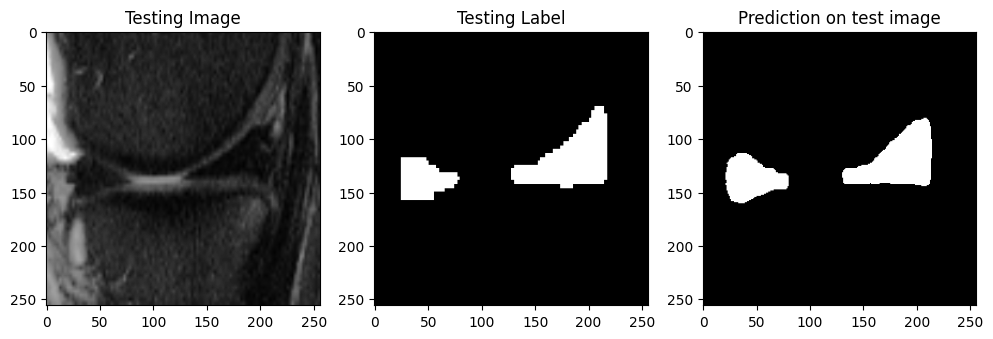

In [ ]:
#######################################################
# Predict on a few images
import random
test_img_number = random.randint(0, len(X_test))
print(test_img_number)
test_img = X_test[test_img_number]
ground_truth=y_test[test_img_number]
test_img_norm=test_img[:,:,:]
test_img_input=np.expand_dims(test_img_norm, 0)
test_img_input1 = preprocess_input1(test_img_input)
test_pred1 = model1.predict(test_img_input1)
test_pred1max= np.argmax(test_pred1, axis=3)[0,:,:]

plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,0], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth[:,:,0], cmap='gray')
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_pred1max, cmap='gray')
plt.show()
#####################################################################

In [ ]:
# Just for testing in trainign images

test_img_number = random.randint(0, len(X_train))
print(test_img_number)
test_img = X_train[test_img_number]
ground_truth=y_train[test_img_number]
test_img_norm=test_img[:,:,:]
test_img_input=np.expand_dims(test_img_norm, 0)
test_img_input1 = preprocess_input1(test_img_input)
test_pred1 = model1.predict(test_img_input1)
test_pred1max= np.argmax(test_pred1, axis=3)[0,:,:]

plt.figure(figsize=(12, 8))
plt.subplot(131)
plt.title('Testing Image')
plt.imshow(test_img[:,:,0], cmap='gray')
plt.subplot(132)
plt.title('Testing Label')
plt.imshow(ground_truth[:,:,0], cmap='gray')
plt.subplot(133)
plt.title('Prediction on test image')
plt.imshow(test_pred1max, cmap='gray')
plt.show()

# Save Sample Images
%cd /content/drive/MyDrive/Students_Lab/Mensical_Lesion/Saved_results
# !ls
plt.imsave('Image'+ str(test_img_number)+'_.jpg', test_img)
plt.imsave('segmented'+ str(test_img_number)+'_.jpg', test_pred1max)
plt.imsave('GT'+ str(test_img_number)+'_.jpg', ground_truth[:,:,0])

# --------------------------------
input_img = test_img
mask_img  = ground_truth
seg_img  = test_pred1max

# select only masked area below
masked = input_img.copy()
masked[mask_img[:,:,0] == 0] = 0

fig, axes = plt.subplots(1, 3, figsize=(16, 12))
ax = axes.flatten()
# View, original, segmented and masked area
ax[0].imshow(input_img, cmap="gray")
ax[0].set_axis_off()
ax[0].set_title("Original Imput Image", fontsize=12)

ax[1].imshow(mask_img, cmap="gray")
ax[1].set_axis_off()
ax[1].set_title("Mask", fontsize=12)

ax[2].imshow(masked, cmap="gray")
ax[2].set_axis_off()
ax[2].set_title("Masked", fontsize=12)

plt.show()

# View IOU
IOU_with_error_view(seg_img, mask_img)

In [ ]:

# print(np.unique(input_img))
# print(np.shape(mask_img[:,:,0]))
# print(np.unique(mask_img))
# print(np.unique(seg_img))

In [ ]:
print(test_pred1[0][:,:,:].shape)

In [ ]:
# # Save Sample Images
# %cd /content/drive/MyDrive/Students_Lab/Mensical_Lesion/Saved_results
# !ls
# plt.imsave('Image'+ str(test_img_number)+'_.jpg', test_img)
# plt.imsave('segmented'+ str(test_img_number)+'_.jpg', test_pred1max)
# plt.imsave('GT'+ str(test_img_number)+'_.jpg', ground_truth[:,:,0])

In [ ]:
# View the Error Image
%cd  /content/drive/MyDrive/Students_Lab/Mensical_Lesion/Saved_results
!ls

In [ ]:
# Compute the IOU and the error image
def IOU_with_error_view(prediction, mask_img):
  intersection = np.logical_and(prediction, mask_img[:,:,0])
  print(prediction.shape)
  print(mask_img[:,:,0].shape)
  print(intersection.shape)
  union = np.logical_or(prediction, mask_img[:,:,0])
  print(union.shape)
  iou_score = np.sum(intersection) / np.sum(union)
  print(iou_score)
 # View Results
  plt.figure(figsize=(12, 8))
  plt.subplot(131)
  plt.title('Segmentation Result')
  plt.imshow(prediction, cmap='gray')
  plt.subplot(132)
  plt.title('Intersection')
  plt.imshow(intersection, cmap='gray')
  plt.subplot(133)
  plt.title('Union')
  plt.imshow(union, cmap='gray')
  # View error
  Error = np.logical_xor(seg_img, mask_img[:,:,0])
  plt.title('Error_Image')
  plt.imshow(Error, cmap='gray')
